# VALORANT AI Coaching System — Data Preparation and Benchmark Construction

**2523424**

CS5500 MSc Dissertation 

Supervisor: Dr. Stephen Swift

This notebook covers the data understanding and data preparation phases of the
project, following the CRISP-DM methodology. It loads professional VALORANT
Champions Tour (VCT) match data covering 2021–2026, cleans it, and constructs
the professional benchmarks against which an individual player's performance is
compared by the coaching system.

**Data source:** VCT 2021–2026 dataset (Kaggle)

## 0. Environment setup

Installs the packages required by this notebook. `pyarrow` is required to write
the cleaned dataset in Parquet format. This cell only needs to be run once per
environment.

In [ ]:
%pip install pandas numpy matplotlib pyarrow
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and initial load

Imports the libraries used throughout the notebook and loads a single year of
player statistics to verify the data path and file structure before processing
all six years. The 2025 file contains 17,996 records across 25 columns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# CHANGE THIS to your extracted archive folder
DATA_DIR = r"C:\Users\aakab\OneDrive\Desktop\Dissertation\val dataset"
YEARS = ["2021", "2022", "2023", "2024", "2025", "2026"]

# Load one file to check everything works
df = pd.read_csv(f"{DATA_DIR}/vct_2025/players_stats/players_stats.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head(5)

Rows: 17996
Columns: 25


,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,"Kill, Assist, Trade, Survive %",Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutches (won/played),Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
0,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,astra,26,0.68,129.0,0.61,69%,89.0,0.42,0.15,0.12,0.12,44%,NaN,0/4,11,11,18,4,3,3
1,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,omen,19,0.46,98.0,0.40,42%,55.0,0.32,0.26,0.05,0.26,37%,33%,1/3,6,6,15,5,1,5
2,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,"astra, omen",45,0.59,114.0,0.52,58%,74.0,0.38,0.20,0.09,0.18,41%,14%,1/7,11,17,33,9,4,8
3,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,fade,26,1.21,219.0,1.13,81%,147.0,0.69,0.38,0.08,0.04,23%,33%,1/3,18,18,16,10,2,1
4,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,sova,19,1.02,220.0,0.75,58%,142.0,0.63,0.26,0.05,0.05,28%,NaN,0/4,12,12,16,5,1,1


## 2. Data understanding

Examines the structure of the dataset: the data type of each column and the
extent of missing values.

Three issues are identified:

1. **Percentages stored as text.** `Headshot %`, `Kill, Assist, Trade, Survive %`
   and `Clutch Success %` are stored as strings (e.g. "44%") and cannot be used
   in numerical analysis without conversion.

2. **Apparent missing clutch data.** `Clutch Success %` is missing in 63.0% of
   records and `Clutches (won/played)` in 26.3%. This is investigated in
   Section 3 and found not to be missing data in the conventional sense.

3. **Duplicate aggregate records.** Inspection of individual rows shows that the
   same player appears multiple times for a single match series once per agent
   used, plus an additional row combining them. In the example shown, the player
   "Boo" has records for astra (26 rounds) and omen (19 rounds), followed by a
   combined "astra, omen" record of 45 rounds. This is addressed in Section 3.

A further group of columns (Rating, Average Damage Per Round, First Kills/Deaths
Per Round, Headshot %, KAST %) are missing in approximately 7.5% of records,
reflecting incomplete statistical coverage in some earlier matches.

In [3]:
# What columns do we have, and what type is each?
print("=== COLUMNS AND TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES (only columns with gaps) ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("No missing values")
else:
    for col, n in missing.items():
        print(f"  {col:40s} {n:6,} missing  ({n/len(df)*100:.1f}%)")

print("\n=== FIRST 3 ROWS ===")
print(df.head(3).to_string())

=== COLUMNS AND TYPES ===
Tournament                            str
Stage                                 str
Match Type                            str
Player                                str
Teams                                 str
Agents                                str
Rounds Played                       int64
Rating                            float64
Average Combat Score              float64
Kills:Deaths                      float64
Kill, Assist, Trade, Survive %        str
Average Damage Per Round          float64
Kills Per Round                   float64
Assists Per Round                 float64
First Kills Per Round             float64
First Deaths Per Round            float64
Headshot %                            str
Clutch Success %                      str
Clutches (won/played)                 str
Maximum Kills in a Single Map       int64
Kills                               int64
Deaths                              int64
Assists                             int64
First Ki

## 3. Data cleaning

Defines the cleaning function applied to every year of data, addressing the
issues identified above.

**Percentage conversion.** Text percentages are stripped of the "%" symbol and
converted to numeric values.

**Recovering clutch data.** Inspection showed that every record in which a player
won zero clutches had a blank `Clutch Success %`, indicating that the blank
represents 0%, not an absent measurement. Recomputing the value from
`Clutches (won/played)` increases the number of usable clutch records from 6,659
to 13,263 in the 2025 data. This matters methodologically: treating these as
missing would have systematically excluded the weakest clutch performances,
inflating the resulting benchmark. Records where no clutch situation occurred are
correctly retained as missing, since no performance can be inferred.

**Flagging aggregate rows.** Rows containing multiple agents were confirmed to be
aggregates of the corresponding single-agent rows: across 300 player/match groups
tested, the aggregate round count equalled the sum of the individual rows in every
case. These account for 26.73% of the 2025 data (4,811 of 17,996 records) and
25.00% of the combined 2021–2026 dataset (92,785 of 371,113 records). Including
them would double-count players in any benchmark calculation.

They are flagged rather than removed, because aggregate rows are appropriate for
overall per-player benchmarks, while single-agent rows are required for
agent-specific benchmarks. Retaining both preserves this flexibility.

In [4]:
def clean_players_stats(df):
    """Clean a players_stats dataframe: convert text percentages to numbers,
    parse clutches, and flag aggregate (multi-agent) rows."""
    df = df.copy()

    # 1. Convert "44%" -> 44.0
    pct_cols = ['Headshot %', 'Kill, Assist, Trade, Survive %', 'Clutch Success %']
    for col in pct_cols:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce'
        )

    # 2. Parse "1/3" -> clutches_won=1, clutches_played=3
    clutch = df['Clutches (won/played)'].astype(str).str.split('/', expand=True)
    df['Clutches Won']    = pd.to_numeric(clutch[0], errors='coerce')
    df['Clutches Played'] = pd.to_numeric(clutch[1], errors='coerce')

    # 3. Recompute clutch success (fixes the "0 won = blank" quirk)
    df['Clutch Success % (clean)'] = np.where(
        df['Clutches Played'] > 0,
        df['Clutches Won'] / df['Clutches Played'] * 100,
        np.nan   # genuinely no clutch situations = unknown, not 0
    )

    # 4. Flag aggregate rows (multiple agents = a total, not a real performance)
    df['is_aggregate'] = df['Agents'].astype(str).str.contains(',')

    # 5. Tidy the agent name on single-agent rows
    df['Agent'] = np.where(df['is_aggregate'], np.nan,
                           df['Agents'].astype(str).str.strip().str.lower())
    return df


clean = clean_players_stats(df)

print("Aggregate rows flagged:", clean['is_aggregate'].sum())
print("Single-agent rows:     ", (~clean['is_aggregate']).sum())

print("\nClutch success recovered:")
print("  original non-null:", clean['Clutch Success %'].notna().sum())
print("  cleaned non-null: ", clean['Clutch Success % (clean)'].notna().sum())

print("\nCheck the Boo example:")
print(clean[clean['Player']=='Boo'][
    ['Agents','Agent','is_aggregate','Rounds Played','Headshot %','Clutches Won','Clutches Played','Clutch Success % (clean)']
].head(3).to_string(index=False))

Aggregate rows flagged: 4811
Single-agent rows:      13185

Clutch success recovered:
  original non-null: 6659
  cleaned non-null:  13263

Check the Boo example:
     Agents Agent  is_aggregate  Rounds Played  Headshot %  Clutches Won  Clutches Played  Clutch Success % (clean)
      astra astra         False             26        44.0           0.0              4.0                  0.000000
       omen  omen         False             19        37.0           1.0              3.0                 33.333333
astra, omen   NaN          True             45        41.0           1.0              7.0                 14.285714


## 4. Loading and combining all years (2021–2026)

Applies the cleaning function to each year and combines the results into a
single dataset of 371,113 records, of which 204,989 are single-agent records
with at least 20 rounds played. The minimum-rounds threshold excludes very small
samples, where per-round statistics are unreliable.

The distribution of records across years is highly uneven: 2021 contains 194,966
records and 2022 contains 126,641, compared with 5,231–17,996 for 2023–2026.
Investigation showed this reflects a structural change in the competition rather
than a data quality problem: 2021 covers 142 tournaments and 10,850 players,
including open qualifier circuits containing amateur and semi-professional
competitors, whereas 2025 covers 15 tournaments and 313 players following VCT's
transition to a franchised, invitation-only format.

This distinction is important, as the earlier data does not represent exclusively
elite performance. It directly informs the benchmark design in Section 5.

In [5]:
def load_all_years(data_dir, years):
    """Load and clean players_stats for every year, adding a Year column."""
    frames = []
    for y in years:
        path = f"{data_dir}/vct_{y}/players_stats/players_stats.csv"
        raw = pd.read_csv(path)
        cleaned = clean_players_stats(raw)
        cleaned['Year'] = int(y)
        frames.append(cleaned)
        print(f"  {y}: {len(cleaned):>7,} rows loaded")
    return pd.concat(frames, ignore_index=True)


print("Loading all years...")
all_years = load_all_years(DATA_DIR, YEARS)

print(f"\nTotal rows: {len(all_years):,}")
print(f"Years:      {sorted(all_years['Year'].unique())}")

# Rows usable for per-agent analysis: single agent + meaningful sample
usable = all_years[(~all_years['is_aggregate']) & (all_years['Rounds Played'] >= 20)]
print(f"Usable single-agent rows (20+ rounds): {len(usable):,}")

print("\nRows per year:")
print(all_years.groupby('Year').size().to_string())

Loading all years...
  2021: 194,966 rows loaded
  2022: 126,641 rows loaded
  2023:  11,249 rows loaded
  2024:  15,030 rows loaded
  2025:  17,996 rows loaded
  2026:   5,231 rows loaded

Total rows: 371,113
Years:      [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Usable single-agent rows (20+ rounds): 204,989

Rows per year:
Year
2021    194966
2022    126641
2023     11249
2024     15030
2025     17996
2026      5231


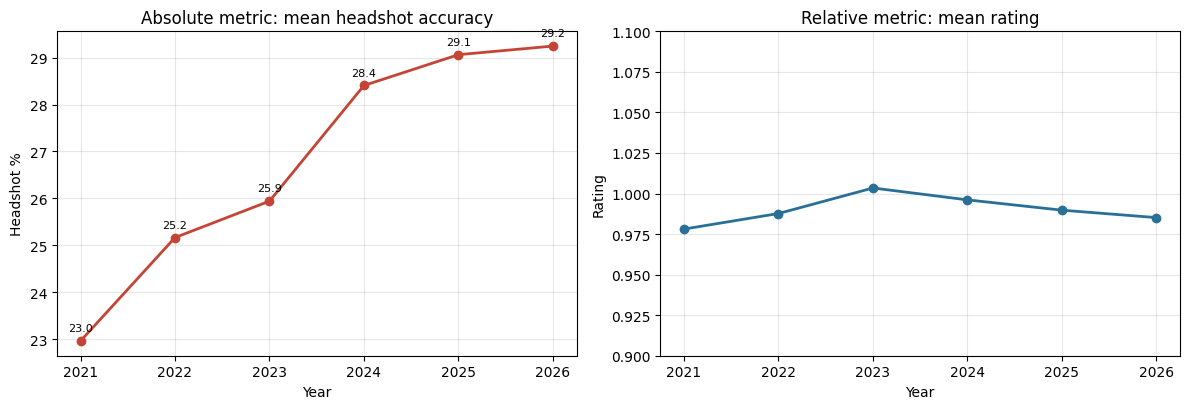

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

base = all_years[(~all_years['is_aggregate']) & (all_years['Rounds Played'] >= 20)]
yearly = base.groupby('Year').agg(
    headshot=('Headshot %', 'mean'),
    rating=('Rating', 'mean')
).reset_index()

# Absolute metric — drifts upward
axes[0].plot(yearly['Year'], yearly['headshot'], marker='o', lw=2, color='#C44536')
axes[0].set_title('Absolute metric: mean headshot accuracy')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Headshot %')
axes[0].grid(alpha=0.3)
for _, r in yearly.iterrows():
    axes[0].annotate(f"{r['headshot']:.1f}", (r['Year'], r['headshot']),
                     textcoords="offset points", xytext=(0, 7),
                     ha='center', fontsize=8)

# Relative metric — stable
axes[1].plot(yearly['Year'], yearly['rating'], marker='o', lw=2, color='#2A6F97')
axes[1].set_title('Relative metric: mean rating')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Rating')
axes[1].set_ylim(0.9, 1.1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 1: Temporal drift in absolute versus relative performance metrics,
2021–2026.** 

Mean headshot accuracy (left) rises consistently from 23.0% in 2021
to 29.2% in 2026, with the steepest increase between 2023 and 2024. Mean rating
(right) remains close to 1.0 throughout, varying only between 0.978 and 1.003,
as it is normalised within matches and therefore cannot capture absolute changes
in standard of play.

This divergence supports applying different year windows to different metric
types: relative metrics can draw on all six years to maximise sample size, while
absolute metrics are restricted to 2024–2026 so that players are compared against
current professional standards rather than a historical average that would set a
materially easier benchmark.

## 5. Overall professional benchmarks

Constructs percentile benchmarks (10th, 25th, 50th, 75th, 90th) for each
performance metric.

**Percentiles rather than means.** A mean indicates only whether a player is
above or below average. Percentiles quantify the magnitude of the gap, allowing
the coaching feedback to distinguish between marginal and substantial
underperformance, and to express targets in terms a player can act on.

**Metric-specific year windows.** Comparing metrics across years shows that
relative measures (Rating, Average Combat Score, Kills:Deaths) remain broadly
stable, since they are normalised within matches mean Rating varies only
between 0.978 and 1.003 across the six years. Absolute skill measures, however,
drift upward: mean headshot accuracy rises from 23.0% in 2021 to 29.2% in 2026,
reflecting both improving standards and the shift to an exclusively elite player
pool.

Relative metrics therefore draw on all six years, giving samples of approximately
162,000–205,000 records, while absolute metrics are restricted to 2024–2026
(approximately 19,000–20,000 records) so that players are compared against
current professional standards rather than a historical average.

**Limitation.** `Clutch Success %` returns 0.00 at the 10th, 25th and 50th
percentiles, because most players win no clutches within a single tournament
record. Percentile comparison is therefore uninformative across the lower half of
the distribution, and this metric is treated as secondary in the coaching system.

In [7]:
# Which year window suits each metric
METRIC_WINDOWS = {
    'Rating':                         'all',
    'Average Combat Score':           'all',
    'Kills:Deaths':                   'all',
    'Kills Per Round':                'all',
    'Assists Per Round':              'all',
    'Headshot %':                     'recent',
    'Average Damage Per Round':       'recent',
    'First Kills Per Round':          'recent',
    'First Deaths Per Round':         'recent',
    'Kill, Assist, Trade, Survive %': 'recent',
    'Clutch Success % (clean)':       'recent',
}

RECENT_YEARS = [2024, 2025, 2026]
PERCENTILES  = [10, 25, 50, 75, 90]


def build_overall_benchmarks(df, min_rounds=20):
    """Percentile benchmarks per metric, using the appropriate year window."""
    base = df[(~df['is_aggregate']) & (df['Rounds Played'] >= min_rounds)]

    rows = []
    for metric, window in METRIC_WINDOWS.items():
        sub = base if window == 'all' else base[base['Year'].isin(RECENT_YEARS)]
        series = pd.to_numeric(sub[metric], errors='coerce').dropna()
        if len(series) < 100:
            continue

        row = {'metric': metric, 'window': window,
               'n': len(series), 'mean': round(series.mean(), 2)}
        for p in PERCENTILES:
            row[f'p{p}'] = round(series.quantile(p/100), 2)
        rows.append(row)

    return pd.DataFrame(rows)


overall_benchmarks = build_overall_benchmarks(all_years)
print(overall_benchmarks.to_string(index=False))

                        metric window      n   mean    p10    p25    p50    p75    p90
                        Rating    all 162005   0.98   0.67   0.82   0.98   1.14   1.30
          Average Combat Score    all 204953 201.11 139.00 166.00 198.00 232.00 267.00
                  Kills:Deaths    all 204989   1.03   0.60   0.77   0.99   1.22   1.50
               Kills Per Round    all 204989   0.70   0.46   0.57   0.69   0.82   0.95
             Assists Per Round    all 204989   0.26   0.11   0.17   0.24   0.34   0.43
                    Headshot % recent  19283  28.87  19.00  23.00  28.00  34.00  40.00
      Average Damage Per Round recent  20435 128.99  92.00 109.00 128.00 148.00 167.00
         First Kills Per Round recent  20442   0.10   0.02   0.05   0.09   0.14   0.20
        First Deaths Per Round recent  20443   0.10   0.03   0.05   0.09   0.14   0.19
Kill, Assist, Trade, Survive % recent  19283  71.25  60.00  66.00  71.00  77.00  82.00
      Clutch Success % (clean) recent  1624

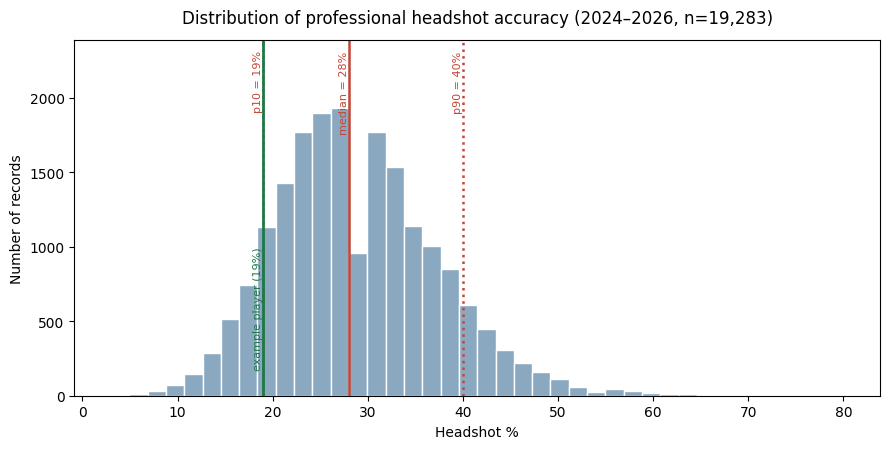

In [8]:
recent = all_years[(~all_years['is_aggregate'])
                   & (all_years['Rounds Played'] >= 20)
                   & (all_years['Year'].isin(RECENT_YEARS))]
hs = pd.to_numeric(recent['Headshot %'], errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(hs, bins=40, color='#8AA9C1', edgecolor='white')

# add headroom above the bars so rotated labels don't reach the title
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
top = ax.get_ylim()[1]

# percentile markers
for p, style, label in [(10, ':', 'p10'), (50, '-', 'median'), (90, ':', 'p90')]:
    v = hs.quantile(p / 100)
    ax.axvline(v, color='#C44536', ls=style, lw=1.8)
    ax.annotate(f"{label} = {v:.0f}%", (v, top * 0.97), rotation=90,
                ha='right', va='top', fontsize=8, color='#C44536')

# where the example player sits (lower, so it clears the p10 label)
ax.axvline(19, color='#1D7A46', lw=2)
ax.annotate('example player (19%)', (19, top * 0.42), rotation=90,
            ha='right', va='top', fontsize=8, color='#1D7A46')

ax.set_title(f'Distribution of professional headshot accuracy '
             f'(2024–2026, n={len(hs):,})', pad=12)
ax.set_xlabel('Headshot %')
ax.set_ylabel('Number of records')
plt.tight_layout()
plt.show()

**Figure 2: Distribution of professional headshot accuracy, 2024–2026
(n = 19,283).** 

The distribution is approximately normal, centred on a median of
28%, with the 10th and 90th percentiles at 19% and 40% respectively.

The example player's accuracy of 19% coincides with the 10th percentile,
indicating that approximately 90% of professional records exceed it. This
illustrates the value of percentile positioning over comparison against a mean:
rather than reporting only that the player is below average, the system can
quantify how far below, allowing feedback to distinguish between marginal and
substantial underperformance.

## 6. Agent-specific benchmarks

Constructs separate benchmarks for each agent, restricted to 2024–2026.

**Why recent years only.** Ten agents in the current roster did not exist in
2021 (Chamber, Fade, Gekko, Harbor, Iso, Neon, Tejo, Veto, Vyse and Waylay), and
the map pool has almost entirely rotated, with only four maps common to both
2021 and 2026. Agent benchmarks drawn from older data would therefore be either
unavailable or unrepresentative of current play.

**Why agent-specific benchmarks are necessary.** The resulting table shows clear
role differentiation across 27 agents. Duelists record high combat scores and
entry rates but few assists Jett has a median Average Combat Score of 225.0 and
0.19 first kills per round, with 0.14 assists. Controllers show the opposite
pattern Omen records 183.0 and 0.07 first kills, with 0.38 assists. Initiators
are higher still on assists, with KAY/O at 0.53 per round.

Comparing a player against a role-agnostic average would therefore misrepresent
their performance: an Omen player scoring 183 is performing at the median for
their agent, but would appear substantially below the overall professional median
of 198.

A minimum sample of 50 records per agent is applied. Agents close to this
threshold, such as Reyna (n=60), yield correspondingly less reliable benchmarks
than those with larger samples such as Omen (n=2,322).

In [9]:
AGENT_METRICS = [
    'Rating', 'Average Combat Score', 'Headshot %',
    'Kills Per Round', 'Assists Per Round',
    'First Kills Per Round', 'First Deaths Per Round',
    'Average Damage Per Round', 'Kill, Assist, Trade, Survive %',
]


def build_agent_benchmarks(df, min_rounds=20, min_sample=50):
    """Median and upper-quartile benchmarks per agent, using recent years only.

    Recent years only because ten agents in the current roster did not exist
    in 2021, and agent balance changes materially between years.
    """
    base = df[
        (~df['is_aggregate'])
        & (df['Rounds Played'] >= min_rounds)
        & (df['Year'].isin(RECENT_YEARS))
        & (df['Agent'].notna())
    ]

    rows = []
    for agent, group in base.groupby('Agent'):
        if len(group) < min_sample:      # skip agents with too little data
            continue
        row = {'agent': agent, 'n': len(group)}
        for metric in AGENT_METRICS:
            series = pd.to_numeric(group[metric], errors='coerce').dropna()
            if len(series) < 20:
                continue
            row[f'{metric}_p50'] = round(series.median(), 2)
            row[f'{metric}_p75'] = round(series.quantile(0.75), 2)
        rows.append(row)

    return pd.DataFrame(rows).sort_values('n', ascending=False)


agent_benchmarks = build_agent_benchmarks(all_years)

print(f"Agents with sufficient data: {len(agent_benchmarks)}\n")
show = ['agent', 'n', 'Average Combat Score_p50', 'Headshot %_p50',
        'Kills Per Round_p50', 'First Kills Per Round_p50', 'Assists Per Round_p50']
print(agent_benchmarks[show].to_string(index=False))

Agents with sufficient data: 27

    agent    n  Average Combat Score_p50  Headshot %_p50  Kills Per Round_p50  First Kills Per Round_p50  Assists Per Round_p50
     omen 2322                     183.0            30.0                 0.65                       0.07                   0.38
    viper 2238                     198.0            29.0                 0.69                       0.08                   0.27
     sova 1699                     186.0            28.0                 0.64                       0.06                   0.26
     raze 1447                     227.0            23.0                 0.78                       0.17                   0.18
   cypher 1424                     189.0            31.0                 0.68                       0.08                   0.21
     fade 1280                     177.0            28.0                 0.62                       0.05                   0.31
     jett 1169                     225.0            29.0               

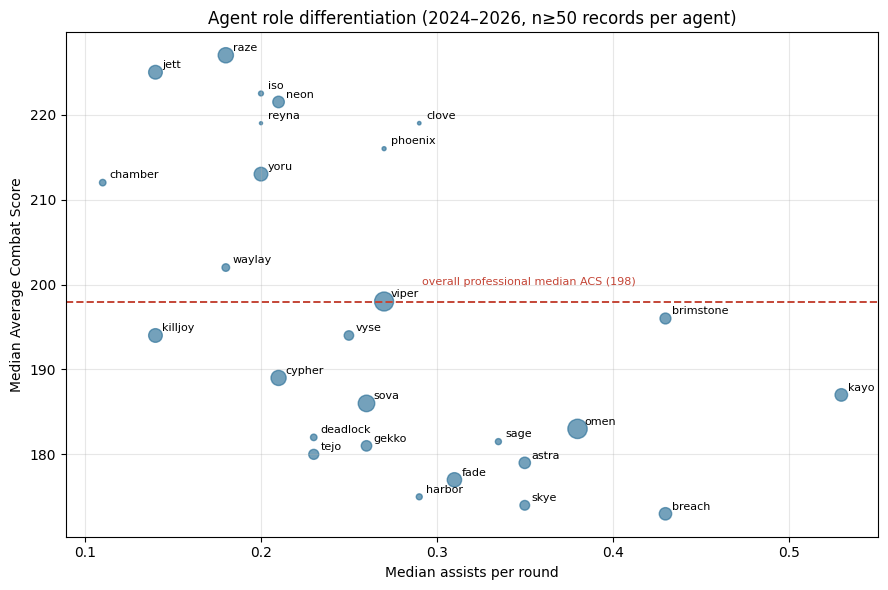

In [10]:
rec = all_years[(~all_years['is_aggregate'])
                & (all_years['Rounds Played'] >= 20)
                & (all_years['Year'].isin(RECENT_YEARS))
                & (all_years['Agent'].notna())]

ag = rec.groupby('Agent').agg(
    acs=('Average Combat Score', 'median'),
    assists=('Assists Per Round', 'median'),
    n=('Agent', 'size')
)
ag = ag[ag['n'] >= 50]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(ag['assists'], ag['acs'], s=ag['n']/12, alpha=0.65, color='#2A6F97')

for name, r in ag.iterrows():
    ax.annotate(name, (r['assists'], r['acs']),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.axhline(198, color='#C44536', ls='--', lw=1.4)
ax.annotate('overall professional median ACS (198)', (ag['assists'].max()*0.55, 200),
            fontsize=8, color='#C44536')

ax.set_xlabel('Median assists per round')
ax.set_ylabel('Median Average Combat Score')
ax.set_title('Agent role differentiation (2024–2026, n≥50 records per agent)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 3: Agent role differentiation across 27 agents, 2024–2026
(n ≥ 50 records per agent).** 

Marker size is proportional to sample size.

A clear inverse relationship is visible between combat score and assist rate,
corresponding to agent roles. Duelists cluster in the upper left, combining high
combat scores with low assist rates Raze (227 ACS, 0.18 assists per round) and
Jett (225, 0.14). Initiators and controllers occupy the lower right, with KAY/O
recording the highest assist rate at 0.53 per round on a median combat score of
187, and Omen at 183 with 0.38 assists.

Notably, the majority of agents fall below the overall professional median combat
score of 198 while performing normally for their role. Evaluating an Omen player
against the role-agnostic median would therefore misidentify median performance
for that agent as substantial underperformance. This confirms the need for
agent-specific benchmarks within the comparison engine.

## 7. Player-to-benchmark comparison engine

Compares an individual player's statistics against the professional benchmarks
and returns, for each metric, their percentile position and a classification
(strength / above median / below median / priority weakness).

`LOWER_IS_BETTER` identifies metrics where a lower value indicates better
performance (First Deaths Per Round), inverting the percentile so that a high
percentile consistently denotes good performance across all metrics.

**Demonstration of agent-aware comparison.** The test player records 0.16 first
deaths per round. Measured against all professional records this falls at the
18.2nd percentile and is classified a priority weakness. Measured against Jett
players specifically it falls at the 54.9th percentile slightly above the agent
median of 0.17 and is unremarkable, since Jett is an entry duelist for whom
frequent opening deaths are an expected consequence of the role.

Without agent context the system would advise this player to enter less
aggressively, which would be actively counterproductive. This example
demonstrates why role-aware benchmarking is essential to generating valid
coaching feedback, and it is used as a test case throughout development.

The structured output of this function forms the input to the LLM feedback
component described in the following chapter.

In [11]:
LOWER_IS_BETTER = {'First Deaths Per Round'}


def build_distributions(df, min_rounds=20):
    """Full value distributions per metric (needed for percentile ranking)."""
    base = df[(~df['is_aggregate']) & (df['Rounds Played'] >= min_rounds)]
    out = {}
    for metric, window in METRIC_WINDOWS.items():
        sub = base if window == 'all' else base[base['Year'].isin(RECENT_YEARS)]
        series = pd.to_numeric(sub[metric], errors='coerce').dropna()
        if len(series) >= 100:
            out[metric] = series.values
    return out


def build_agent_distributions(df, agent, min_rounds=20):
    """Same, but restricted to one agent."""
    base = df[(~df['is_aggregate']) & (df['Rounds Played'] >= min_rounds)
              & (df['Year'].isin(RECENT_YEARS)) & (df['Agent'] == agent)]
    out = {}
    for metric in METRIC_WINDOWS:
        series = pd.to_numeric(base[metric], errors='coerce').dropna()
        if len(series) >= 20:
            out[metric] = series.values
    return out


def percentile_of(value, distribution):
    """What % of professional records fall below this value."""
    return float((distribution < value).mean() * 100)


def classify(pct, lower_is_better=False):
    if lower_is_better:
        pct = 100 - pct
    if pct >= 75: return "strength"
    if pct >= 50: return "above median"
    if pct >= 25: return "below median"
    return "priority weakness"


def compare_player(player_stats, distributions, agent_distributions=None):
    """Compare a player's stats against pro benchmarks, overall and per-agent."""
    rows = []
    for metric, value in player_stats.items():
        if metric not in distributions or value is None:
            continue
        dist = distributions[metric]
        lower_better = metric in LOWER_IS_BETTER
        pct = percentile_of(value, dist)

        row = {
            'metric': metric,
            'player': value,
            'pro_median': round(float(np.median(dist)), 2),
            'percentile': round(100 - pct if lower_better else pct, 1),
            'verdict': classify(pct, lower_better),
        }
        if agent_distributions and metric in agent_distributions:
            adist = agent_distributions[metric]
            apct = percentile_of(value, adist)
            row['agent_median'] = round(float(np.median(adist)), 2)
            row['agent_percentile'] = round(100 - apct if lower_better else apct, 1)
        rows.append(row)

    return pd.DataFrame(rows)


# --- Test with a made-up player ---
distributions = build_distributions(all_years)
jett_dist = build_agent_distributions(all_years, 'jett')

test_player = {
    'Average Combat Score': 165, 'Headshot %': 19, 'Kills Per Round': 0.58,
    'First Kills Per Round': 0.07, 'First Deaths Per Round': 0.16,
    'Kill, Assist, Trade, Survive %': 64, 'Rating': 0.82,
}

result = compare_player(test_player, distributions, jett_dist)
print(result.to_string(index=False))
print("\nPriority weaknesses:",
      list(result[result['verdict'] == 'priority weakness']['metric']))

                        metric  player  pro_median  percentile           verdict  agent_median  agent_percentile
          Average Combat Score  165.00      198.00        23.8 priority weakness        225.00               9.6
                    Headshot %   19.00       28.00         9.3 priority weakness         29.00               8.6
               Kills Per Round    0.58        0.69        26.1      below median          0.80               9.8
         First Kills Per Round    0.07        0.09        36.2      below median          0.19               4.1
        First Deaths Per Round    0.16        0.09        18.2 priority weakness          0.17              54.9
Kill, Assist, Trade, Survive %   64.00       71.00        17.6 priority weakness         70.00              22.3
                        Rating    0.82        0.98        24.4 priority weakness          1.03              18.3

Priority weaknesses: ['Average Combat Score', 'Headshot %', 'First Deaths Per Round', 'Kill, As

## 8. Saving processed outputs

Writes the cleaned dataset, the benchmark tables and the configuration to disk,
so that the coaching system loads pre-computed benchmarks at runtime rather than
reprocessing 371,113 records on every request.

`benchmark_config.json` records the parameters used to construct the benchmarks
(year windows per metric, minimum round and sample thresholds, and metric
direction), ensuring the process is documented and reproducible.

Note that when the Parquet file is reloaded, the `is_aggregate` column should be
cast back to boolean before use.

In [12]:
import os
import json

OUTPUT_DIR = "processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Cleaned dataset (all years, cleaned columns)
all_years.to_parquet(f"{OUTPUT_DIR}/vct_all_years_clean.parquet", index=False)

# 2. Benchmark tables
overall_benchmarks.to_csv(f"{OUTPUT_DIR}/benchmarks_overall.csv", index=False)
agent_benchmarks.to_csv(f"{OUTPUT_DIR}/benchmarks_by_agent.csv", index=False)

# 3. Config, so the choices are documented alongside the data
config = {
    "metric_windows": METRIC_WINDOWS,
    "recent_years": RECENT_YEARS,
    "lower_is_better": list(LOWER_IS_BETTER),
    "min_rounds": 20,
    "min_agent_sample": 50,
    "source": "VCT 2021-2026 (Kaggle)",
}
with open(f"{OUTPUT_DIR}/benchmark_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved to", os.path.abspath(OUTPUT_DIR))
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    print(f"  {f:35s} {size:8.1f} KB")

Saved to c:\Users\aakab\OneDrive\Desktop\Dissertation\val dataset\processed
  benchmark_config.json                    0.6 KB
  benchmarks_by_agent.csv                  3.2 KB
  benchmarks_overall.csv                   0.7 KB
  vct_all_years_clean.parquet           9023.5 KB
